<a href="https://colab.research.google.com/github/PavanSurisetti/Glucoma_Using_Machine_Learning/blob/main/Glucoma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install opendatasets


#**FULL CODE WITH VISUALIZATIONS**

Using device: cuda
Classes: ['0', '1']
Train samples: 8621
Val samples: 5755
Test samples: 2874
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 171MB/s]


Epoch [1/10] Loss: 0.4188 Train Acc: 0.8121
Epoch [2/10] Loss: 0.3062 Train Acc: 0.8647
Epoch [3/10] Loss: 0.2671 Train Acc: 0.8863
Epoch [4/10] Loss: 0.2366 Train Acc: 0.8980
Epoch [5/10] Loss: 0.2070 Train Acc: 0.9105
Epoch [6/10] Loss: 0.1827 Train Acc: 0.9223
Epoch [7/10] Loss: 0.1614 Train Acc: 0.9333
Epoch [8/10] Loss: 0.1406 Train Acc: 0.9392
Epoch [9/10] Loss: 0.1288 Train Acc: 0.9454
Epoch [10/10] Loss: 0.1144 Train Acc: 0.9567
Training Completed!

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1754
           1       0.96      0.98      0.97      1120

    accuracy                           0.98      2874
   macro avg       0.97      0.98      0.97      2874
weighted avg       0.98      0.98      0.98      2874

Confusion Matrix:
[[1710   44]
 [  25 1095]]
ROC-AUC Score: 0.9980793899657925


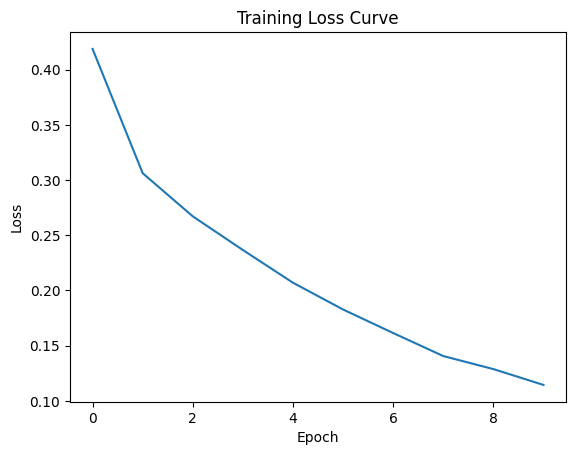

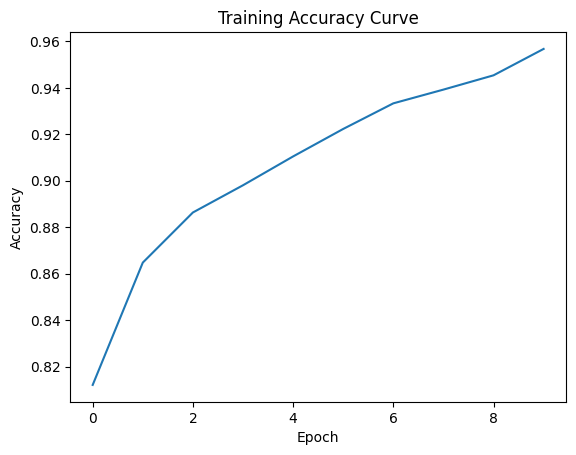

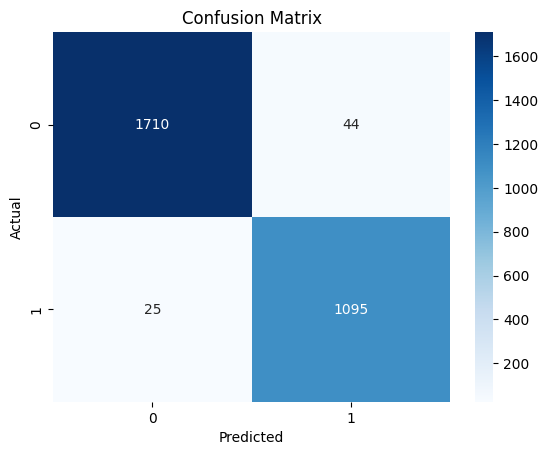

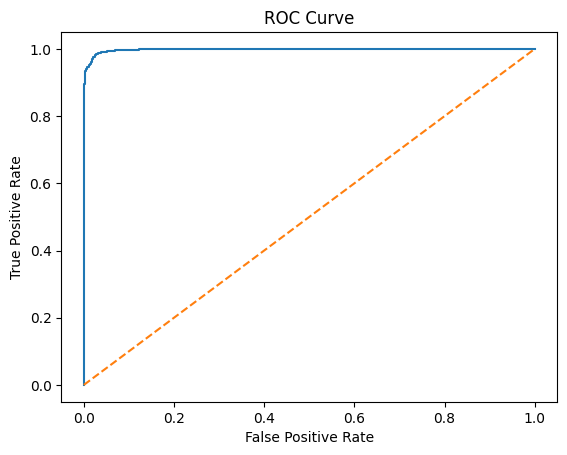

In [5]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# 2. DEVICE
# =========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================
# 3. DATA PATH
# =========================================
data_dir = "/content/drive/MyDrive/glucoma-private-dataset/glucoma_private_dataset"

# =========================================
# 4. TRANSFORMS
# =========================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# =========================================
# 5. LOAD DATASETS
# =========================================
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

# =========================================
# 6. LOAD PRETRAINED MODEL
# =========================================
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 1)

model = model.to(device)

# =========================================
# 7. LOSS & OPTIMIZER
# =========================================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# =========================================
# 8. TRAINING
# =========================================
train_losses = []
train_accuracies = []

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds.int() == labels.int()).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Train Acc: {epoch_acc:.4f}")

print("Training Completed!")

# =========================================
# 9. TEST EVALUATION
# =========================================
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

auc_score = roc_auc_score(all_labels, all_probs)
print("ROC-AUC Score:", auc_score)

# =========================================
# 10. VISUALIZATIONS
# =========================================

# 🔹 Loss Curve
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 🔹 Accuracy Curve
plt.figure()
plt.plot(train_accuracies)
plt.title("Training Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# 🔹 Confusion Matrix
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔹 ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()